## 0. Improvement Strategy

- alignment module training with blip2 q-former.
- references: RaDialog (arxiv:2311.18681v2).

## 1. Import Library

In [1]:
# import necessary libraries
import os
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, BertModel, Blip2QFormerConfig, Blip2QFormerModel
from transformers.models.blip_2.modeling_blip_2 import Blip2TextEmbeddings
from health_multimodal.image import get_image_inference
from health_multimodal.image.utils import ImageModelType

c:\Users\Baihaqie\anaconda3\envs\ai_work\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
# setup reproducibility
def seed_everything(seed=42):
    import random
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

In [ ]:
# setup global configuration
config = {
    "experiment": "exp_002",
    "stage": "stage_a",

    "data": {
        "train_path": r"D:\VLM-Research_Task-C\data\processed\chexpert_plus\train.parquet",
        "dev_path": r"D:\VLM-Research_Task-C\data\processed\chexpert_plus\dev_internal.parquet",
        "test_path": r"D:\VLM-Research_Task-C\data\processed\chexpert_plus\test.parquet",
        "image_col": "actual_image_path",
        "label_suffix": "_label",
        "max_text_length": 512
    },

    "model": {
        # q-former uses its own tokenizer (bert-base-uncased) and shares weights with text branch
        "qformer_tokenizer_name": "bert-base-uncased",
        "qformer_init_from": "bert-base-uncased",   # source for self-attention/ffn weights (cross-attn remains random)
        "qformer_hidden_size": 768,                 # bert-base default, not 1024 (unlike exp_001)
        "qformer_num_hidden_layers": 12,            # full bert depth; reduce if resources limited
        "qformer_num_attention_heads": 12,
        "qformer_intermediate_size": 3072,
        "cross_attention_frequency": 2,              # blip-2 convention: cross-attn every 2 layers
        "num_query_tokens": 32,                      
        "itc_proj_dim": 256,                         # separate contrastive embedding space (not hidden_dim directly)
        "llm_hidden_dim": 1024,                      # must match biogpt hidden_size (interface contract)
        "dropout": 0.1
    },

    "train": {
        "batch_size": 16,
        "num_epochs": 15,
        "lr": 1.0e-4,
        "weight_decay": 1.0e-4,
        "grad_clip_norm": 1.0,
        "early_stopping_patience": 3,
        "num_workers": 0,
        "seed": 42
    },

    "loss": {
        "use_lm": False  # enables image-grounded language modeling (itg) loss
    },

    "output": {
        "checkpoint_dir": r"D:\VLM-Research_Task-C\output\exp_002\stage_a\checkpoints",
        "log_dir": r"D:\VLM-Research_Task-C\output\exp_002\stage_a\logs",
        "plot_dir": r"D:\VLM-Research_Task-C\output\exp_002\stage_a\plots",
        "best_model_filename": "stage_a_best.pt"
    },

    "device": "cuda"
}

# create output directories
for key in ["checkpoint_dir", "log_dir", "plot_dir"]:
    os.makedirs(config["output"][key], exist_ok=True)

In [4]:
# define device, fallback to cpu if cuda not available
device = torch.device(config['device'] if torch.cuda.is_available() else 'cpu')
print(f"using device: {device}")

using device: cuda


## 2. Load Dataset

In [5]:
# load into a dataframe for each set
df_train = pd.read_parquet(config['data']['train_path'])
df_dev = pd.read_parquet(config['data']['dev_path'])
df_test = pd.read_parquet(config['data']['test_path'])

In [6]:
# quick exploration

# dataset dimension
print(f"train set: {df_train.shape[0]} rows & {df_train.shape[1]} columns")
print(f"dev set: {df_dev.shape[0]} rows & {df_dev.shape[1]} columns")
print(f"test set: {df_test.shape[0]} rows & {df_test.shape[1]} columns")

# extract CXR pathology label columns (not directly used in stage-a, but kept for dataset interface)
label_cols = [col for col in df_train.columns if col.endswith(config['data']['label_suffix'])]
print(f"label columns ({len(label_cols)}): {label_cols}")

# make sure there are 14 CXR pathology labels
assert len(label_cols) == 14, "there have to be 14 CXR pathology labels"

train set: 189529 rows & 77 columns
dev set: 33563 rows & 77 columns
test set: 234 rows & 77 columns
label columns (14): ['Enlarged Cardiomediastinum_label', 'Cardiomegaly_label', 'Lung Opacity_label', 'Lung Lesion_label', 'Edema_label', 'Consolidation_label', 'Pneumonia_label', 'Atelectasis_label', 'Pneumothorax_label', 'Pleural Effusion_label', 'Pleural Other_label', 'Fracture_label', 'Support Devices_label', 'No Finding_label']


## 3. Training Utilities

### 3.1 Dataset Class

In [7]:
class StageADataset(Dataset):
    def __init__(self, df, image_col, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_col = image_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row[self.image_col]
        try:
            image = Image.open(img_path).convert('L')
        except FileNotFoundError:
            print(f"warning: image not found {img_path}, returning zeros.")
            image = Image.new('L', (224, 224))
        if self.transform:
            image = self.transform(image)
        target_text = row["target_report_text"]
        return image, target_text

### 3.2 Load BioViL-T Image Encoder

In [8]:
# load biovil-t image encoder
image_engine = get_image_inference(ImageModelType.BIOVIL_T)
biovilt_transform = image_engine.transform
bio_model = image_engine.model
bio_model.to(device)
bio_model.eval()

# freeze biovil-t weights
for param in bio_model.parameters():
    param.requires_grad = False

print("biovil-t loaded successfully (frozen)")

biovil-t loaded successfully (frozen)


In [9]:
# detect vision hidden dimension
sample_row = df_train.iloc[0]
sample_img_path = sample_row[config['data']['image_col']]
try:
    sample_img = Image.open(sample_img_path).convert('L')
except FileNotFoundError:
    sample_img = Image.new('L', (224, 224))

sample_pixel_values = biovilt_transform(sample_img).unsqueeze(0).to(device)

with torch.no_grad():
    dummy_out = bio_model(sample_pixel_values)

    if hasattr(dummy_out, 'patch_embeddings'):
        features = dummy_out.patch_embeddings
        print("using patch_embeddings")
    elif hasattr(dummy_out, 'last_hidden_state'):
        features = dummy_out.last_hidden_state
        print("using last_hidden_state")
    else:
        if isinstance(dummy_out, torch.Tensor):
            features = dummy_out
            print("using raw tensor output")
        else:
            try:
                features = bio_model.encoder(sample_pixel_values)
                print("using encoder output")
            except:
                raise RuntimeError("cannot extract features from biovil-t output")

    if features.dim() == 3:
        vision_dim = features.shape[-1]
    elif features.dim() == 4:
        vision_dim = features.shape[1]
    else:
        vision_dim = features.shape[-1]

    # sanity check: fallback if dimension is unexpectedly small
    if vision_dim < 100:
        print(f"warning: detected vision_dim={vision_dim}, which is suspiciously small.")
        print("fallback to 512 (default patch_embeddings dimension).")
        vision_dim = 512

config['vision_dim'] = vision_dim
print(f"vision hidden dimension: {vision_dim}")

using patch_embeddings
vision hidden dimension: 512


In [10]:
# define feature extractor function
def extract_spatial_features(backbone, images):
    """extract spatial features from BioViL-T, flatten to [B, N_patches, D]."""
    with torch.no_grad():
        out = backbone(images)
        if hasattr(out, 'patch_embeddings'):
            features = out.patch_embeddings
            if features.dim() == 4:
                B, C, H, W = features.shape
                features = features.flatten(2).transpose(1, 2)  # (B, H*W, C)
            return features
        elif hasattr(out, 'last_hidden_state'):
            features = out.last_hidden_state
            if features.dim() == 4:
                B, C, H, W = features.shape
                features = features.flatten(2).transpose(1, 2)
            return features
        else:
            raise ValueError("BioViL-T output format not recognized")

### 3.3 Load Tokenizer for Q-Former (bert-base-uncased)

q-former tokenizer loaded: bert-base-uncased


Token indices sequence length is longer than the specified maximum sequence length for this model (519 > 512). Running this sequence through the model will result in indexing errors


min: 8
max: 986
mean: 93.7
95th percentile: 199.0
99th percentile: 297.0


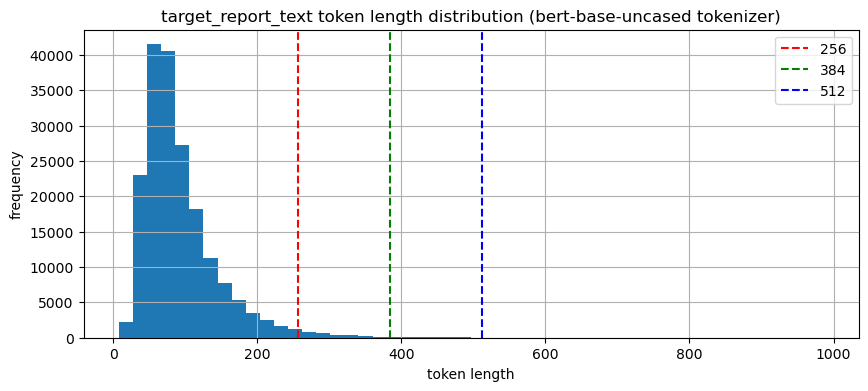

In [11]:
qformer_tokenizer = AutoTokenizer.from_pretrained(config['model']['qformer_tokenizer_name'])
print(f"q-former tokenizer loaded: {config['model']['qformer_tokenizer_name']}")

# quick distribution of token lengths (for max_text_length)
sample_texts = df_train['target_report_text'].tolist()
token_lengths = [len(qformer_tokenizer.encode(t, add_special_tokens=True)) for t in sample_texts]

print(f"min: {min(token_lengths)}")
print(f"max: {max(token_lengths)}")
print(f"mean: {np.mean(token_lengths):.1f}")
print(f"95th percentile: {np.percentile(token_lengths, 95):.1f}")
print(f"99th percentile: {np.percentile(token_lengths, 99):.1f}")

plt.figure(figsize=(10, 4))
plt.hist(token_lengths, bins=50)
plt.axvline(256, color='r', linestyle='--', label='256')
plt.axvline(384, color='g', linestyle='--', label='384')
plt.axvline(512, color='b', linestyle='--', label='512')
plt.xlabel('token length')
plt.ylabel('frequency')
plt.legend()
plt.title('target_report_text token length distribution (bert-base-uncased tokenizer)')
plt.grid(True)
plt.show()

### 3.4 Create Datasets and Dataloaders

In [12]:
train_ds = StageADataset(df_train, config['data']['image_col'], transform=biovilt_transform)
dev_ds = StageADataset(df_dev, config['data']['image_col'], transform=biovilt_transform)

train_loader = DataLoader(train_ds, batch_size=config['train']['batch_size'], shuffle=True, num_workers=config['train']['num_workers'], pin_memory=True)
dev_loader = DataLoader(dev_ds, batch_size=config['train']['batch_size'], shuffle=False, num_workers=config['train']['num_workers'], pin_memory=True)

print(f"train batches: {len(train_loader)}, dev batches: {len(dev_loader)}")

train batches: 23692, dev batches: 4196


### 3.5 Build BLIP-2 Q-Former (pre-trained, bert-initialized)

In [13]:
qformer_config = Blip2QFormerConfig(
    vocab_size=qformer_tokenizer.vocab_size,
    hidden_size=config['model']['qformer_hidden_size'],
    num_hidden_layers=config['model']['qformer_num_hidden_layers'],
    num_attention_heads=config['model']['qformer_num_attention_heads'],
    intermediate_size=config['model']['qformer_intermediate_size'],
    hidden_dropout_prob=config['model']['dropout'],
    attention_probs_dropout_prob=config['model']['dropout'],
    cross_attention_frequency=config['model']['cross_attention_frequency'],
    encoder_hidden_size=config['vision_dim'],
    # required so each Blip2QFormerLayer builds its own text-only `intermediate`/`output`
    # submodules (used whenever query_length == 0, i.e. the text-only ITC branch). without
    # this, text-only forward passes hit: AttributeError: 'Blip2QFormerLayer' object has no
    # attribute 'intermediate'.
    use_qformer_text_input=True,
)
print(qformer_config)

Blip2QFormerConfig {
  "attention_probs_dropout_prob": 0.1,
  "cross_attention_frequency": 2,
  "encoder_hidden_size": 512,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "blip_2_qformer",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "transformers_version": "5.5.0",
  "use_qformer_text_input": true,
  "vocab_size": 30522
}



In [14]:
def init_qformer_from_bert(qformer: Blip2QFormerModel, bert_source_name: str):
    """
    copy embeddings + self-attention/ffn (non-cross-attention) weights from bert-base-uncased
    to the q-former, following the canonical blip-2 / radialog initialization recipe:
      - embeddings, self-attention, intermediate, output layers -> copied from pretrained bert
      - cross-attention layers -> left randomly initialized (no cross-modal checkpoint for cxr)
    defensive try/except per tensor to avoid silent failures across transformers versions.
    """
    bert = BertModel.from_pretrained(bert_source_name)
    bert_state = bert.state_dict()
    qformer_state = qformer.state_dict()

    copied, skipped = 0, 0
    for name, param in qformer_state.items():
        # skip cross-attention and q-former-specific modules (keep random)
        if 'crossattention' in name or '_query' in name:
            skipped += 1
            continue
        # map qformer.encoder.layer -> bert.encoder.layer (same bertlayer structure)
        candidate_name = name.replace('qformer.', '') if name.startswith('qformer.') else name
        if candidate_name in bert_state and bert_state[candidate_name].shape == param.shape:
            qformer_state[name] = bert_state[candidate_name].clone()
            copied += 1
        else:
            skipped += 1

    qformer.load_state_dict(qformer_state)
    print(f"init_qformer_from_bert: {copied} tensors copied from '{bert_source_name}', "
          f"{skipped} skipped (cross-attn / qformer-specific or name mismatch, kept random)")
    return qformer

def init_text_embeddings_from_bert(text_embeddings: "Blip2TextEmbeddings", bert_source_name: str):
    """
    copy word_embeddings + position_embeddings from bert-base-uncased into a standalone
    Blip2TextEmbeddings module. needed because (in recent `transformers` versions)
    Blip2QFormerModel no longer owns an embeddings layer itself - it only accepts a
    pre-computed `query_embeds` tensor. text input_ids must therefore be embedded
    externally (via this module) before being handed to the q-former.
    """
    bert = BertModel.from_pretrained(bert_source_name)
    bert_state = bert.state_dict()

    copied, skipped = 0, 0
    with torch.no_grad():
        for name in ["word_embeddings.weight", "position_embeddings.weight"]:
            bert_name = f"embeddings.{name}"
            local_param = dict(text_embeddings.named_parameters())[name]
            if bert_name in bert_state and bert_state[bert_name].shape == local_param.shape:
                local_param.copy_(bert_state[bert_name])
                copied += 1
            else:
                skipped += 1

    print(f"init_text_embeddings_from_bert: {copied} tensors copied from '{bert_source_name}', {skipped} skipped")
    return text_embeddings


In [15]:
qformer = Blip2QFormerModel(qformer_config).to(device)
qformer = init_qformer_from_bert(qformer, config['model']['qformer_init_from'])

# learnable query tokens - blip-2 initialization convention
query_tokens = nn.Parameter(torch.zeros(1, config['model']['num_query_tokens'], config['model']['qformer_hidden_size'])).to(device)
nn.init.normal_(query_tokens, mean=0.0, std=qformer_config.initializer_range)

print(f"q-former initialized with {sum(p.numel() for p in qformer.parameters())/1e6:.2f}M params")
print(f"query_tokens shape: {tuple(query_tokens.shape)}")

# standalone text-embeddings module (word + position embeddings).
# required because Blip2QFormerModel in this transformers version does not accept
# `input_ids` directly - it only accepts a pre-computed `query_embeds` tensor, so text
# tokens must be embedded externally via this module before being passed to the q-former.
qformer_text_embeddings = Blip2TextEmbeddings(qformer_config).to(device)
qformer_text_embeddings = init_text_embeddings_from_bert(qformer_text_embeddings, config['model']['qformer_init_from'])
print(f"text embeddings initialized with {sum(p.numel() for p in qformer_text_embeddings.parameters())/1e6:.2f}M params")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


init_qformer_from_bert: 120 tensors copied from 'bert-base-uncased', 206 skipped (cross-attn / qformer-specific or name mismatch, kept random)
q-former initialized with 153.57M params
query_tokens shape: (1, 32, 768)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


init_text_embeddings_from_bert: 2 tensors copied from 'bert-base-uncased', 0 skipped
text embeddings initialized with 23.83M params


### 3.6 Define Projection Heads and Task Specific Modules

In [16]:
class ITCProjectionHeads(nn.Module):
    """
    separate projection heads for image and text into a contrastive space (itc_proj_dim).
    following blip-2 design: independent linear projections, not shared with llm_proj.
    """
    def __init__(self, qformer_hidden_size, itc_proj_dim):
        super().__init__()
        self.image_proj = nn.Linear(qformer_hidden_size, itc_proj_dim)
        self.text_proj = nn.Linear(qformer_hidden_size, itc_proj_dim)

    def forward_image(self, query_output):
        # query_output: (B, num_query_tokens, qformer_hidden_size) -> (B, num_query_tokens, itc_proj_dim)
        return F.normalize(self.image_proj(query_output), dim=-1)

    def forward_text(self, text_cls_output):
        # text_cls_output: (B, qformer_hidden_size) -> (B, itc_proj_dim)
        return F.normalize(self.text_proj(text_cls_output), dim=-1)

class ITMHead(nn.Module):
    """binary classifier for image-text matching (match / no-match)."""
    def __init__(self, qformer_hidden_size, dropout=0.1):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(qformer_hidden_size, 2)  # [no-match, match]
        )

    def forward(self, query_output_itm):
        # mean-pool over query tokens before classification
        pooled = query_output_itm.mean(dim=1)
        return self.classifier(pooled)

itc_heads = ITCProjectionHeads(config['model']['qformer_hidden_size'], config['model']['itc_proj_dim']).to(device)
itm_head = ITMHead(config['model']['qformer_hidden_size'], dropout=config['model']['dropout']).to(device)

# projection to biogpt hidden dimension (1024) — this is the interface to stage-meeting
llm_proj = nn.Linear(config['model']['qformer_hidden_size'], config['model']['llm_hidden_dim']).to(device)

print(f"itc_heads: {sum(p.numel() for p in itc_heads.parameters())/1e6:.2f}M params")
print(f"itm_head: {sum(p.numel() for p in itm_head.parameters())/1e6:.2f}M params")
print(f"llm_proj: {sum(p.numel() for p in llm_proj.parameters())/1e6:.2f}M params") 

itc_heads: 0.39M params
itm_head: 0.00M params
llm_proj: 0.79M params


In [17]:
class LMHead(nn.Module):
    """
    image-grounded text generation head (itg).
    tied to q-former's word embeddings (bert weight tying convention).
    """
    def __init__(self, text_embeddings, vocab_size, hidden_size):
        super().__init__()
        self.dense = nn.Linear(hidden_size, hidden_size)
        self.activation = nn.GELU()
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.decoder = nn.Linear(hidden_size, vocab_size, bias=False)
        self.bias = nn.Parameter(torch.zeros(vocab_size))
        # tie weights to the standalone text-embeddings module's word embeddings
        # (qformer itself no longer owns an embeddings layer in this transformers version)
        self.decoder.weight = text_embeddings.word_embeddings.weight

    def forward(self, hidden_states):
        x = self.activation(self.dense(hidden_states))
        x = self.layer_norm(x)
        return self.decoder(x) + self.bias

if config['loss']['use_lm']:
    lm_head = LMHead(qformer_text_embeddings, qformer_config.vocab_size, config['model']['qformer_hidden_size']).to(device)
    print(f"lm_head: {sum(p.numel() for p in lm_head.parameters())/1e6:.2f}M params (decoder weight tied)")
else:
    lm_head = None
    print("lm_head disabled (use_lm=False)")

lm_head disabled (use_lm=False)


### 3.7 Define Q-Former Forward Branches for Different Objectives

In [18]:
def qformer_image_branch(qformer, query_tokens, visual_features):
    """
    query cross-attends to visual_features only (no text self-attention).
    output: query_output (B, num_query_tokens, qformer_hidden_size)
    """
    batch_size = visual_features.size(0)
    queries = query_tokens.expand(batch_size, -1, -1)
    image_atts = torch.ones(visual_features.size()[:-1], dtype=torch.long, device=visual_features.device)

    output = qformer(
        query_embeds=queries,
        encoder_hidden_states=visual_features,
        encoder_attention_mask=image_atts,
        return_dict=True,
    )
    return output.last_hidden_state  # (B, num_query_tokens, qformer_hidden_size)

def qformer_text_branch(qformer, input_ids, attention_mask):
    """
    text-only self-attention, TANPA cross-attention (encoder_hidden_states=None) dan TANPA query tokens -
    murni encode teks sendirian, sesuai desain text branch BLIP-2 asli untuk sisi teks pada ITC.

    NOTE: in this transformers version Blip2QFormerModel no longer embeds input_ids itself -
    it only accepts a pre-computed `query_embeds` tensor. so we embed input_ids ourselves via
    the standalone `qformer_text_embeddings` module (global, initialized in an earlier cell)
    before calling the q-former.
    """
    query_embeds = qformer_text_embeddings(input_ids=input_ids)  # (B, text_len, H)
    output = qformer(
        query_embeds=query_embeds,
        query_length=0,
        attention_mask=attention_mask,
        encoder_hidden_states=None,
        return_dict=True,
    )
    return output.last_hidden_state[:, 0, :]  # posisi [CLS]

def qformer_itm_branch(qformer, query_tokens, input_ids, attention_mask, visual_features):
    """
    joint self-attention: queries and text tokens are concatenated.
    queries cross-attend to visual features, text does NOT cross-attend directly,
    but benefits from the shared self-attention with queries that carry visual information.
    returns only the query portion of the joint output.

    NOTE: `qformer_text_embeddings` (global) builds the concatenated [queries ; text_embeds]
    tensor - Blip2QFormerModel only accepts that pre-computed `query_embeds` tensor, not
    raw input_ids, in this transformers version.
    """
    batch_size = visual_features.size(0)
    queries = query_tokens.expand(batch_size, -1, -1)
    query_atts = torch.ones(queries.size()[:-1], dtype=torch.long, device=queries.device)
    joint_attention_mask = torch.cat([query_atts, attention_mask], dim=1)
    image_atts = torch.ones(visual_features.size()[:-1], dtype=torch.long, device=visual_features.device)

    # concatenated [queries ; embedded text tokens] -> (B, num_query + text_len, H)
    query_embeds = qformer_text_embeddings(input_ids=input_ids, query_embeds=queries)

    output = qformer(
        query_embeds=query_embeds,
        query_length=queries.size(1),
        attention_mask=joint_attention_mask,
        encoder_hidden_states=visual_features,
        encoder_attention_mask=image_atts,
        return_dict=True,
    )
    num_query_tokens = queries.size(1)
    return output.last_hidden_state[:, :num_query_tokens, :]  # query part only

def build_itg_attention_mask(query_len, text_attention_mask):
    """
    build a 4d attention mask for itg with mixed attention:
      - queries: bidirectional (can attend to each other)
      - text: causal (can only attend to previous text tokens + all queries)
      - queries cannot attend to text at all.
    this mimics the lavis/blip-2 manual mask construction.
    returns an additive mask (0 -> -inf, 1 -> 0) suitable for `attention_mask` in transformers.
    """
    batch_size, text_len = text_attention_mask.shape
    total_len = query_len + text_len
    device = text_attention_mask.device

    # causal mask for text part
    causal_text = torch.tril(torch.ones(text_len, text_len, device=device))

    mask = torch.zeros(total_len, total_len, device=device)
    mask[:query_len, :query_len] = 1.0                 # query <-> query: bidirectional
    mask[query_len:, :query_len] = 1.0                  # text -> query: allowed
    mask[query_len:, query_len:] = causal_text          # text -> text: causal
    # query -> text remains 0 (not allowed)

    mask = mask.unsqueeze(0).expand(batch_size, -1, -1).clone()  # (B, total_len, total_len)

    # apply padding mask for text tokens
    text_pad = text_attention_mask.unsqueeze(1).expand(-1, total_len, -1).float()  # (B, total_len, text_len)
    mask[:, :, query_len:] = mask[:, :, query_len:] * text_pad

    extended_mask = mask.unsqueeze(1)  # (B, 1, total_len, total_len)
    # convert to additive mask: 0 -> -inf, 1 -> 0
    extended_mask = (1.0 - extended_mask) * torch.finfo(torch.float32).min
    return extended_mask

def qformer_itg_branch(qformer, query_tokens, input_ids, attention_mask, visual_features):
    """
    causal language modeling (itg) forward pass:
      - queries cross-attend to image and have bidirectional self-attention among themselves.
      - text attends causally to previous text and to all queries (but not to future text).
    returns the text hidden states (after the query part).
    """
    batch_size = visual_features.size(0)
    queries = query_tokens.expand(batch_size, -1, -1)
    query_len = queries.size(1)
    image_atts = torch.ones(visual_features.size()[:-1], dtype=torch.long, device=visual_features.device)

    itg_attention_mask = build_itg_attention_mask(query_len, attention_mask)

    # concatenated [queries ; embedded text tokens], same as the itm branch -
    # qformer only accepts a pre-computed `query_embeds` tensor, not raw input_ids.
    query_embeds = qformer_text_embeddings(input_ids=input_ids, query_embeds=queries)

    output = qformer(
        query_embeds=query_embeds,
        query_length=query_len,
        attention_mask=itg_attention_mask,  # already extended (4d)
        encoder_hidden_states=visual_features,
        encoder_attention_mask=image_atts,
        return_dict=True,
    )
    return output.last_hidden_state[:, query_len:, :]  # text part only

### 3.8 Define Loss Functions 

In [19]:
def contrastive_loss_blip2(image_embeds_itc, text_embeds_itc, temperature=0.07):
    """
    blip-2 style contrastive loss: image has multiple query embeddings,
    similarity is the maximum over queries (not mean).
    """
    # sim[i, j, q] = image_embeds_itc[i, q] . text_embeds_itc[j]
    sim_q2t = torch.einsum('iqd,jd->ijq', image_embeds_itc, text_embeds_itc)
    sim_matrix, _ = sim_q2t.max(dim=-1)  # (B_img, B_txt) - max over queries
    sim_matrix = sim_matrix / temperature

    labels = torch.arange(sim_matrix.size(0), device=sim_matrix.device)
    loss_i2t = F.cross_entropy(sim_matrix, labels)
    loss_t2i = F.cross_entropy(sim_matrix.T, labels)
    loss = (loss_i2t + loss_t2i) / 2
    return loss, sim_matrix.detach()

def mine_hard_negatives(similarity_matrix):
    """return the index of the hardest negative (highest similarity wrong pair) for each row."""
    batch_size = similarity_matrix.size(0)
    diag_mask = torch.eye(batch_size, device=similarity_matrix.device, dtype=torch.bool)
    masked_sim = similarity_matrix.masked_fill(diag_mask, float("-inf"))
    return masked_sim.argmax(dim=1)  # [B]

def itm_loss_blip2(qformer, query_tokens, itm_head, tokenized_texts, hard_neg_idx, visual_features):
    """
    image-text matching loss with hard negatives.
    runs joint self-attention twice (positive and negative pairs) via qformer_itm_branch.
    """
    input_ids = tokenized_texts["input_ids"]
    attention_mask = tokenized_texts["attention_mask"]

    # positive pairs
    pos_query_out = qformer_itm_branch(qformer, query_tokens, input_ids, attention_mask, visual_features)
    pos_logits = itm_head(pos_query_out)

    # negative pairs: hardest-negative text paired with the same image
    neg_input_ids = input_ids[hard_neg_idx]
    neg_attention_mask = attention_mask[hard_neg_idx]
    neg_query_out = qformer_itm_branch(qformer, query_tokens, neg_input_ids, neg_attention_mask, visual_features)
    neg_logits = itm_head(neg_query_out)

    logits = torch.cat([pos_logits, neg_logits], dim=0)
    labels = torch.cat([
        torch.ones(pos_logits.size(0), dtype=torch.long, device=logits.device),
        torch.zeros(neg_logits.size(0), dtype=torch.long, device=logits.device)
    ])
    loss = F.cross_entropy(logits, labels)
    return loss, pos_logits, neg_logits

def itg_loss_blip2(qformer, query_tokens, lm_head, tokenized_texts, visual_features):
    """
    causal language modeling loss (next-token prediction) conditioned on image via queries.
    standard shift-by-1: predict token[t+1] from hidden state at position t.
    """
    input_ids = tokenized_texts["input_ids"]
    attention_mask = tokenized_texts["attention_mask"]

    text_hidden = qformer_itg_branch(qformer, query_tokens, input_ids, attention_mask, visual_features)  # (B, text_len, H)
    logits = lm_head(text_hidden)  # (B, text_len, vocab_size)

    # shift for autoregressive prediction
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = input_ids[:, 1:].contiguous()
    shift_pad_mask = attention_mask[:, 1:].contiguous()

    loss_fct = nn.CrossEntropyLoss(reduction='none')
    losses = loss_fct(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))
    losses = losses.view(shift_labels.shape) * shift_pad_mask  # ignore padded positions
    loss = losses.sum() / shift_pad_mask.sum().clamp(min=1.0)
    return loss

### 3.9 Text Tokenization Helper

In [20]:
def tokenize_text_batch(tokenizer, texts, device, max_length=256):
    """tokenize a batch of texts for the q-former text branches."""
    encoded = tokenizer(list(texts), padding=True, truncation=True, max_length=max_length, return_tensors="pt")
    return {k: v.to(device) for k, v in encoded.items()}

### 3.10 Retrieval Accuracy Helper

In [21]:
def compute_retrieval_accuracy(similarity_matrix):
    """in-batch recall@1 and recall@5 for image-to-text retrieval."""
    batch_size = similarity_matrix.size(0)
    targets = torch.arange(batch_size, device=similarity_matrix.device)
    ranks = similarity_matrix.argsort(dim=1, descending=True)
    correct_pos = (ranks == targets.unsqueeze(1)).float().argmax(dim=1)
    recall1 = (correct_pos < 1).float().mean().item()
    recall5 = (correct_pos < min(5, batch_size)).float().mean().item()
    return {"recall@1": recall1, "recall@5": recall5}

## 4. Train Loop

In [22]:
# collect trainable parameters
trainable_params = (
    list(qformer.parameters()) + [query_tokens] +
    list(qformer_text_embeddings.parameters()) +
    list(itc_heads.parameters()) + list(itm_head.parameters()) + list(llm_proj.parameters())
)
if config['loss']['use_lm']:
    # exclude decoder.weight due to weight tying
    trainable_params += [p for n, p in lm_head.named_parameters() if 'decoder.weight' not in n]

# filter: only parameters that require gradient (and are leaf)
# Note: PyTorch optimizer requires leaf tensors, so we filter out non-leaf
trainable_params = [p for p in trainable_params if p.requires_grad and p.is_leaf]

# safety check
if len(trainable_params) == 0:
    raise RuntimeError("No trainable parameters found!")

optimizer = torch.optim.AdamW(trainable_params, lr=config['train']['lr'], weight_decay=config['train']['weight_decay'])

In [23]:
train_contrastive_losses, train_itm_losses = [], []
val_contrastive_losses, val_itm_losses = [], []
val_recall1s, val_recall5s = [], []
val_itm_accuracies = []
if config['loss']['use_lm']:
    train_lm_losses, val_lm_losses = [], []
else:
    train_lm_losses = val_lm_losses = []

In [24]:
# clear gpu cache before starting
torch.cuda.empty_cache()

In [25]:
print(f"starting training (optimizer: adamw, early stopping based on recall@1, use_lm={config['loss']['use_lm']})")
for epoch in range(1, config['train']['num_epochs'] + 1):
    # ----- training phase -----
    qformer.train()
    itc_heads.train()
    itm_head.train()
    llm_proj.train()
    if config['loss']['use_lm']:
        lm_head.train()
    train_c_loss, train_i_loss, train_lm_loss = 0.0, 0.0, 0.0

    for images, texts in tqdm(train_loader, desc=f"epoch {epoch}/{config['train']['num_epochs']} (train)"):
        images = images.to(device)

        with torch.no_grad():
            visual_features = extract_spatial_features(bio_model, images)  # [B, N_patches, vision_dim]

        tokenized = tokenize_text_batch(qformer_tokenizer, texts, device, config['data']['max_text_length'])

        # image branch (query cross-attend image only)
        image_query_out = qformer_image_branch(qformer, query_tokens, visual_features)
        image_embeds_itc = itc_heads.forward_image(image_query_out)  # [B, num_query, itc_dim]

        # text branch (text-only self-attention, no cross-attn)
        text_cls_out = qformer_text_branch(qformer, tokenized["input_ids"], tokenized["attention_mask"])
        text_embeds_itc = itc_heads.forward_text(text_cls_out)  # [B, itc_dim]

        # contrastive loss (blip-2 style, max-over-query similarity)
        c_loss, sim_matrix = contrastive_loss_blip2(image_embeds_itc, text_embeds_itc)

        # itm loss with hard negatives (joint self-attention branch)
        hard_neg_idx = mine_hard_negatives(sim_matrix)
        i_loss, pos_logits, neg_logits = itm_loss_blip2(qformer, query_tokens, itm_head, tokenized, hard_neg_idx, visual_features)

        loss = c_loss + i_loss

        # lm/itg loss - causal generation conditioned on image via queries
        if config['loss']['use_lm']:
            lm_loss = itg_loss_blip2(qformer, query_tokens, lm_head, tokenized, visual_features)
            loss = loss + lm_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable_params, config['train']['grad_clip_norm'])
        optimizer.step()

        train_c_loss += c_loss.item()
        train_i_loss += i_loss.item()
        if config['loss']['use_lm']:
            train_lm_loss += lm_loss.item()

    train_c_loss /= len(train_loader)
    train_i_loss /= len(train_loader)
    train_lm_loss /= len(train_loader)
    train_contrastive_losses.append(train_c_loss)
    train_itm_losses.append(train_i_loss)
    train_lm_losses.append(train_lm_loss)

    # ----- validation phase -----
    qformer.eval()
    itc_heads.eval()
    itm_head.eval()
    llm_proj.eval()
    if config['loss']['use_lm']:
        lm_head.eval()
    val_c_loss, val_i_loss, val_lm_loss = 0.0, 0.0, 0.0
    val_recall1_sum, val_recall5_sum, val_itm_acc_sum = 0.0, 0.0, 0.0

    with torch.no_grad():
        for images, texts in tqdm(dev_loader, desc=f"epoch {epoch}/{config['train']['num_epochs']} (val)"):
            images = images.to(device)
            visual_features = extract_spatial_features(bio_model, images)
            tokenized = tokenize_text_batch(qformer_tokenizer, texts, device, config['data']['max_text_length'])

            image_query_out = qformer_image_branch(qformer, query_tokens, visual_features)
            image_embeds_itc = itc_heads.forward_image(image_query_out)

            text_cls_out = qformer_text_branch(qformer, tokenized["input_ids"], tokenized["attention_mask"])
            text_embeds_itc = itc_heads.forward_text(text_cls_out)

            c_loss, sim_matrix = contrastive_loss_blip2(image_embeds_itc, text_embeds_itc)
            hard_neg_idx = mine_hard_negatives(sim_matrix)
            i_loss, pos_logits, neg_logits = itm_loss_blip2(qformer, query_tokens, itm_head, tokenized, hard_neg_idx, visual_features)

            val_c_loss += c_loss.item()
            val_i_loss += i_loss.item()

            if config['loss']['use_lm']:
                lm_loss = itg_loss_blip2(qformer, query_tokens, lm_head, tokenized, visual_features)
                val_lm_loss += lm_loss.item()

            retrieval = compute_retrieval_accuracy(sim_matrix)
            val_recall1_sum += retrieval["recall@1"]
            val_recall5_sum += retrieval["recall@5"]

            # compute itm head accuracy for positive and negative pairs
            pos_correct = (pos_logits.argmax(dim=1) == 1).float().mean()
            neg_correct = (neg_logits.argmax(dim=1) == 0).float().mean()
            val_itm_acc_sum += ((pos_correct + neg_correct) / 2).item()

    n_batches = len(dev_loader)
    val_c_loss /= n_batches
    val_i_loss /= n_batches
    val_lm_loss /= n_batches
    val_recall1 = val_recall1_sum / n_batches
    val_recall5 = val_recall5_sum / n_batches
    val_itm_acc = val_itm_acc_sum / n_batches

    val_contrastive_losses.append(val_c_loss)
    val_itm_losses.append(val_i_loss)
    val_lm_losses.append(val_lm_loss)
    val_recall1s.append(val_recall1)
    val_recall5s.append(val_recall5)
    val_itm_accuracies.append(val_itm_acc)

    print(f"epoch {epoch}: train_c={train_c_loss:.4f} train_i={train_i_loss:.4f} train_lm={train_lm_loss:.4f} | "
          f"val_c={val_c_loss:.4f} val_i={val_i_loss:.4f} val_lm={val_lm_loss:.4f} | "
          f"R@1={val_recall1:.4f} R@5={val_recall5:.4f} ITM_acc={val_itm_acc:.4f}")

    # early stopping & checkpoint based on val_recall1
    if val_recall1 > best_val_recall1:
        best_val_recall1 = val_recall1
        early_stop_counter = 0
        best_model_path = os.path.join(config['output']['checkpoint_dir'], config['output']['best_model_filename'])
        checkpoint_dict = {
            'epoch': epoch,
            'qformer_state_dict': qformer.state_dict(),
            'qformer_text_embeddings_state_dict': qformer_text_embeddings.state_dict(),
            'query_tokens': query_tokens.detach().cpu(),
            'itc_heads_state_dict': itc_heads.state_dict(),
            'itm_head_state_dict': itm_head.state_dict(),
            'llm_proj_state_dict': llm_proj.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_recall1': best_val_recall1,
        }
        if config['loss']['use_lm']:
            checkpoint_dict['lm_head_state_dict'] = lm_head.state_dict()
        torch.save(checkpoint_dict, best_model_path)
        print(f"  -> new best model saved (recall@1={val_recall1:.4f})")
    else:
        early_stop_counter += 1
        if early_stop_counter >= config['train']['early_stopping_patience']:
            print(f"early stopping triggered at epoch {epoch}")
            break

print(f"\ntraining finished. best validation recall@1: {best_val_recall1:.4f}")

starting training (optimizer: adamw, early stopping based on recall@1, use_lm=False)


epoch 1/15 (train):   0%|          | 0/23692 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 5. Model Evaluation

In [ ]:
# contrastive loss
plt.figure(figsize=(10, 4))
plt.plot(train_contrastive_losses, label='train contrastive')
plt.plot(val_contrastive_losses, label='val contrastive')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('contrastive loss (train vs dev)')
plt.grid(True)
plt.savefig(os.path.join(config['output']['plot_dir'], 'contrastive_loss.png'), dpi=150, bbox_inches='tight')
plt.show()

# itm loss
plt.figure(figsize=(10, 4))
plt.plot(train_itm_losses, label='train ITM')
plt.plot(val_itm_losses, label='val ITM')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('ITM loss (train vs dev)')
plt.grid(True)
plt.savefig(os.path.join(config['output']['plot_dir'], 'itm_loss.png'), dpi=150, bbox_inches='tight')
plt.show()

# lm/itg loss (if enabled)
if config['loss']['use_lm']:
    plt.figure(figsize=(10, 4))
    plt.plot(train_lm_losses, label='train LM/ITG')
    plt.plot(val_lm_losses, label='val LM/ITG')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend()
    plt.title('LM/ITG loss (train vs dev) - causal next-token prediction')
    plt.grid(True)
    plt.savefig(os.path.join(config['output']['plot_dir'], 'lm_itg_loss.png'), dpi=150, bbox_inches='tight')
    plt.show()

# recall and itm accuracy
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.plot(val_recall1s, label='Recall@1')
plt.plot(val_recall5s, label='Recall@5')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.title('retrieval accuracy (dev)')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(val_itm_accuracies, label='ITM accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.title('ITM head accuracy (dev)')
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(config['output']['plot_dir'], 'retrieval_itm_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# interface validation: soft visual tokens shape for stage-meeting

# load best model and check that llm_proj produces tokens with correct dimension
best_model_path = os.path.join(config['output']['checkpoint_dir'], config['output']['best_model_filename'])
checkpoint = torch.load(best_model_path)
qformer.load_state_dict(checkpoint['qformer_state_dict'])
qformer_text_embeddings.load_state_dict(checkpoint['qformer_text_embeddings_state_dict'])
query_tokens_loaded = checkpoint['query_tokens'].to(device)
llm_proj.load_state_dict(checkpoint['llm_proj_state_dict'])
if config['loss']['use_lm'] and 'lm_head_state_dict' in checkpoint:
    lm_head.load_state_dict(checkpoint['lm_head_state_dict'])
qformer.eval()
llm_proj.eval()

with torch.no_grad():
    sample_images, sample_texts = next(iter(dev_loader))
    sample_images = sample_images.to(device)
    sample_visual_features = extract_spatial_features(bio_model, sample_images)
    sample_query_out = qformer_image_branch(qformer, query_tokens_loaded, sample_visual_features)
    soft_visual_tokens = llm_proj(sample_query_out)

print(f"soft visual tokens shape: {tuple(soft_visual_tokens.shape)} (expected: [batch, {config['model']['num_query_tokens']}, {config['model']['llm_hidden_dim']}])")
assert soft_visual_tokens.shape[-1] == config['model']['llm_hidden_dim'], "output dim does not match biogpt hidden_size - check llm_proj"
print("interface to stage-meeting verified: soft visual tokens shape is consistent.")

In [ ]:
# (optional) compute perplexity from best epoch's lm loss
if config['loss']['use_lm'] and len(val_lm_losses) > 0:
    best_epoch_idx = val_recall1s.index(max(val_recall1s))
    best_epoch_lm_loss = val_lm_losses[best_epoch_idx]
    perplexity = float(np.exp(best_epoch_lm_loss))
    print(f"val LM/ITG loss at best recall@1 epoch: {best_epoch_lm_loss:.4f}")
    print(f"perplexity: {perplexity:.2f}")
    print("note: perplexity measures q-former's own text generation quality, not the final report quality from biogpt.")

## 6. Training Summary

In [ ]:
summary = f"""
====================================================================
stage-a training summary (exp_002)
====================================================================
experiment: {config['experiment']}
stage: {config['stage']}
device: {device}

dataset:
  - train: {len(df_train)} samples
  - dev: {len(df_dev)} samples
  - test: {len(df_test)} samples

model:
  - alignment module: blip2 q-former (joint self-attention + cross-attention, bert-initialized)
  - qformer hidden size: {config['model']['qformer_hidden_size']}
  - qformer num hidden layers: {config['model']['qformer_num_hidden_layers']}
  - cross attention frequency: {config['model']['cross_attention_frequency']}
  - num query tokens: {config['model']['num_query_tokens']}
  - itc projection dim: {config['model']['itc_proj_dim']}
  - llm projection dim (-> biogpt hidden_size): {config['model']['llm_hidden_dim']}
  - text encoder: q-former itself (bert-base-uncased tokenizer, shared weights)
  - vision dimension (biovil-t): {config['vision_dim']}
  - lm (itg) loss: {'enabled' if config['loss']['use_lm'] else 'disabled'}

training:
  - batch size: {config['train']['batch_size']}
  - learning rate: {config['train']['lr']}
  - weight decay: {config['train']['weight_decay']}
  - epochs: {len(train_contrastive_losses)}
  - best validation recall@1: {best_val_recall1:.4f}
  - final val lm/itg loss (best-recall epoch): {val_lm_losses[val_recall1s.index(max(val_recall1s))]:.4f} {'(perplexity=' + f'{np.exp(val_lm_losses[val_recall1s.index(max(val_recall1s))]):.2f}' + ')' if config['loss']['use_lm'] else ''}

deviation from exp_001 (see documentation for full rationale):
  - alignment module: lightweight nn.transformerdecoder -> blip2 q-former (bert-init, joint self-attn)
  - text encoder: separate frozen pubmedbert -> shared q-former text branch (bert-base-uncased)
  - itm: concat + mlp on pooled embeddings -> joint query-text self-attention through q-former
  - itc: single mean-pooled vector similarity -> multi-query max-similarity (canonical blip-2)

deviation from exp_002 (this notebook's addition):
  - lm/itg loss: excluded (exp_002) -> enabled (causal image-grounded text generation with tied lm_head)

output directory: {config['output']['checkpoint_dir']}
====================================================================
"""

print(summary)

with open(os.path.join(config['output']['log_dir'], 'training_summary.txt'), 'w') as f:
    f.write(summary)

print("\nall done. stage-a (radialog / blip-2 q-former + lm/itg loss) training and evaluation complete.")